<a href="https://colab.research.google.com/github/sobhihamadi/begineer-project/blob/master/Copy_of_script_paint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🟢 Step 3 — Upload your photo

On the left side, click the folder icon 📁

Click Upload

Upload your photo (portrait, family, nature, etc.)

Example:
family.jpg

🟢 Step 4 — Install the tools (first cell)

Click inside the first box
Press the ▶ Play button

Wait until it finishes (about 1–2 minutes).

You will see text scrolling — this is normal.

You only need to do this once per session.



🟢 Step 5 — Tell the notebook which photo to use

In the second box, find this line:

IMAGE_PATH = "input.jpg"


Change it to your photo name, for example:

IMAGE_PATH = "family.jpg"


🟢 Step 6 — Create your paint-by-number

Click the ▶ Run all button

In [1]:
!pip install opencv-python scikit-image numpy matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 20.9 MB/s eta 0:00:00


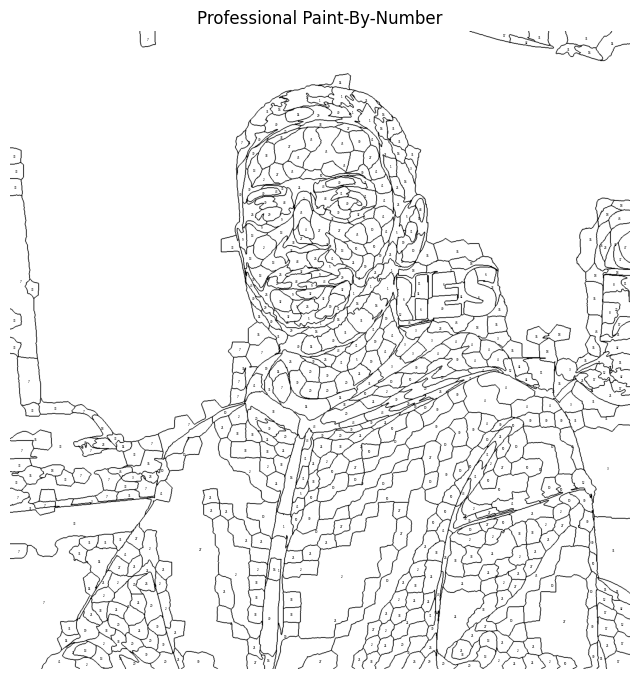

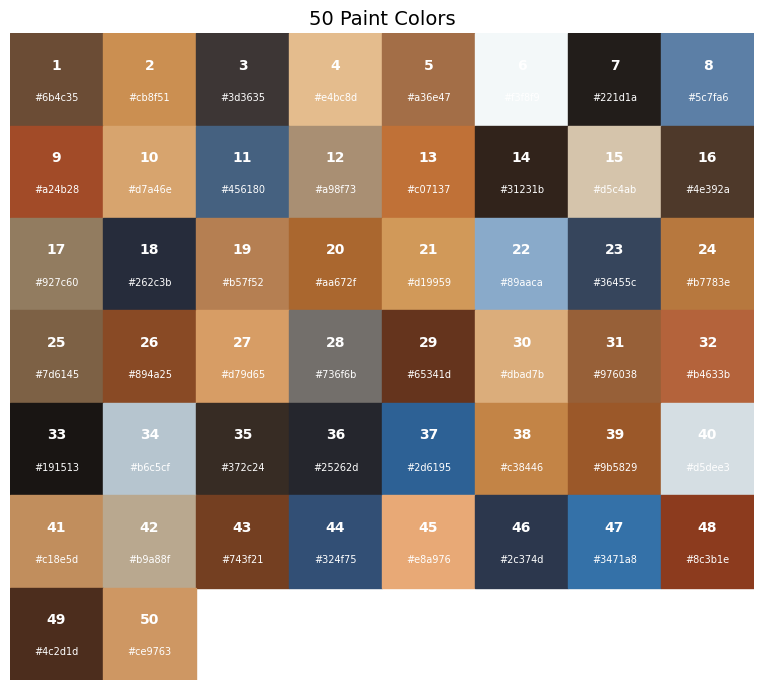

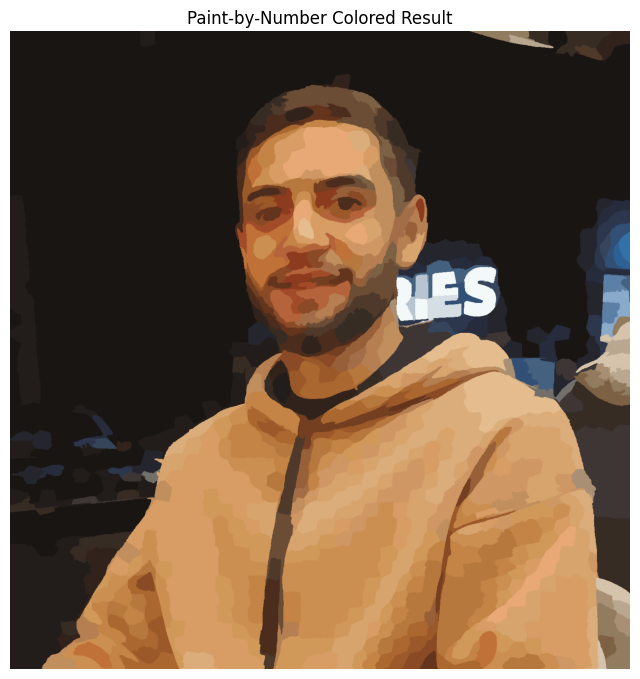

In [4]:

import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import slic, find_boundaries
from skimage.measure import regionprops, label

# =========================
# 1) LOAD
# =========================

IMAGE_PATH = "/content/WhatsApp Image 2024-03-27 at 16.54.33_873080c5.jpg"

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)







# =========================
# 2) SHOW PALETTE GRID
# =========================

def show_palette_grid(palette, cols=8):
    n = len(palette)
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 1.2, rows * 1.2))

    for i, color in enumerate(palette):
        r = rows - 1 - i // cols
        c = i % cols

        hex_color = '#%02x%02x%02x' % tuple(color)

        # Draw color box
        plt.gca().add_patch(
            plt.Rectangle((c, r), 1, 1, color=color / 255)
        )

        # Write color index + hex
        plt.text(c + 0.5, r + 0.65, str(i+1),
                 ha="center", va="center",
                 fontsize=10, color="white", weight="bold")

        plt.text(c + 0.5, r + 0.3, hex_color,
                 ha="center", va="center",
                 fontsize=7, color="white")

    plt.xlim(0, cols)
    plt.ylim(0, rows)
    plt.axis("off")
    plt.title(f"{n} Paint Colors", fontsize=14)
    plt.show()

# =========================
# PARAMETERS
# =========================
N_SEGMENTS = 1800
COMPACTNESS = 8
COLOR_THRESH = 5     # lower = less merging
N_COLORS = 50
MIN_REGION_AREA = 100

# =========================
# 2) EDGE-PRESERVING SMOOTH
# =========================
img = cv2.bilateralFilter(img, 9, 75, 75)

# =========================
# 3) SUPERPIXELS
# =========================
sp = slic(img, n_segments=N_SEGMENTS, compactness=COMPACTNESS, start_label=1)

# =========================
# 4) COMPUTE MEAN COLOR PER SUPERPIXEL
# =========================
sp_ids = np.unique(sp)
sp_color = {}
for sid in sp_ids:
    mask = sp == sid
    sp_color[sid] = img[mask].mean(axis=0)

# =========================
# 5) BUILD ADJACENCY GRAPH
# =========================
neighbors = {sid: set() for sid in sp_ids}

for y in range(sp.shape[0]-1):
    for x in range(sp.shape[1]-1):
        a = sp[y,x]
        b = sp[y,x+1]
        c = sp[y+1,x]
        if a != b:
            neighbors[a].add(b)
            neighbors[b].add(a)
        if a != c:
            neighbors[a].add(c)
            neighbors[c].add(a)

# =========================
# 6) MERGE SUPERPIXELS BY COLOR SIMILARITY
# =========================
parent = {sid: sid for sid in sp_ids}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a,b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

for a in sp_ids:
    for b in neighbors[a]:
        diff = np.linalg.norm(sp_color[a] - sp_color[b])
        if diff < COLOR_THRESH:
            union(a,b)

# =========================
# 7) BUILD FINAL REGIONS
# =========================
merged = np.zeros_like(sp)
mapping = {}
new_id = 1

for sid in sp_ids:
    root = find(sid)
    if root not in mapping:
        mapping[root] = new_id
        new_id += 1
    merged[sp == sid] = mapping[root]

labels = label(merged)

# =========================
# 8) REMOVE SMALL REGIONS
# =========================
for r in regionprops(labels):
    if r.area < MIN_REGION_AREA:
        labels[labels == r.label] = 0

labels = label(labels)

# =========================
# 9) COMPUTE REGION COLORS
# =========================
colors = []
region_ids = []

for r in regionprops(labels):
    mask = labels == r.label
    colors.append(img[mask].mean(axis=0))
    region_ids.append(r.label)

colors = np.array(colors)

# =========================
# 10) MAP TO 10 PAINT COLORS
# =========================
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=N_COLORS, n_init=10).fit(colors)
region_color = {region_ids[i]: kmeans.labels_[i]+1 for i in range(len(region_ids))}
palette = kmeans.cluster_centers_.astype(np.uint8)

# =========================
# 11) DRAW OUTLINES
# =========================
edges = find_boundaries(labels, mode="outer")
canvas = np.ones((*labels.shape,3),dtype=np.uint8)*255
canvas[edges] = [0,0,0]

# =========================
# 12) DRAW NUMBERS
# =========================
plt.figure(figsize=(8,10))
plt.imshow(canvas)
plt.axis("off")

for r in regionprops(labels):
    if r.area > MIN_REGION_AREA:
        y,x = r.centroid
        plt.text(int(x),int(y),str(region_color[r.label]),ha="center",va="center",fontsize=2)

plt.title("Professional Paint-By-Number")
plt.show()



show_palette_grid(palette, cols=8)
# =========================
# 10.5) CREATE COLORED RESULT
# =========================

colored = np.zeros_like(img)

for r in regionprops(labels):
    mask = labels == r.label
    color_index = region_color[r.label] - 1   # 0..9
    colored[mask] = palette[color_index]

plt.figure(figsize=(8,10))
plt.imshow(colored)
plt.axis("off")
plt.title("Paint-by-Number Colored Result")
plt.show()